# **Extreme Classification by Optimizing Compositional Entropic Risk (SCENT and SOX)**

**Author**: Xiyuan Wei


**Introduction**

In this tutorial, you will learn how to train a linear model by optimizing [Compositional Entropic Risk](https://arxiv.org/abs/2602.02877) (CERM) using SCENT and SOX on a subset of TreeOfLife-10M, a biology dataset of 163K species. This version was implementated in PyTorch. It is recommended to run this notebook on a GPU-enabled environment, e.g., [Google Colab](https://colab.research.google.com/).


**Reference**

If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following paper:

<pre>
@article{wei2026geometry,
  title={A Geometry-Aware Efficient Algorithm for Compositional Entropic Risk Minimization},
  author={Wei, Xiyuan and Zhou, Linli and Wang, Bokun and Lin, Chih-Jen and Yang, Tianbao},
  journal={arXiv preprint arXiv:2602.02877},
  year={2026}
}
</pre>

# **Prerequisites**

In [ ]:
# Download pre-computed features
!gdown --folder 'https://drive.google.com/drive/folders/10cY2Azqz9Gnci-r4fXcGIpH_e5YaKXH_?usp=sharing' -O ./features

Retrieving folder contents
Retrieving folder 1cvVXLotOAQsFopyB03LZxA9yuNRXxl2I treeoflife10m_subset
Retrieving folder 1fcoocWaeJZtB1NhC1aXgBp8NCjPrFZTU train
Processing file 1wyrbWXNPjUMBWJvI7B7QEraGkXts3B1t features.pt
Processing file 16U77_XulkLuPdN8gbzy5ZkWZKeoVRBmz labels.pt
Retrieving folder 1Xv0JfbkJpj7boGVQHnOaoNWipAn85uuc val
Processing file 1E8iB9DtYQKRW42WwwOe5Ce7yIDtMk7rY features.pt
Processing file 1wnzdt2tYw1bpdf4016EREKr1k5kMh7rf labels.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1wyrbWXNPjUMBWJvI7B7QEraGkXts3B1t
From (redirected): https://drive.google.com/uc?id=1wyrbWXNPjUMBWJvI7B7QEraGkXts3B1t&confirm=t&uuid=64f4d895-cae6-4181-8ccb-68b8ee4661f0
To: /content/features/treeoflife10m_subset/train/features.pt
100% 1.56G/1.56G [00:10<00:00, 147MB/s]
Downloading...
From: https://drive.google.com/uc?id=16U77_XulkLuPdN8gbzy5ZkWZKeoVRBmz
To: /content/feat

In [ ]:
# Installing LibAUC
!pip install libauc

In [ ]:
import os
import logging
import pathlib
import json
import sys
import random
import math

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

from libauc.losses import EntLossClassification
from libauc.optimizers import SCENT

# **Helper Functions**

## **Model Architecture**

In [ ]:
class LinearClassifier(nn.Module):
    """Linear classifier: maps feature vectors to logits for m classes.

    forward(x): expects shape (B, D) and returns logits (B, m)
    """

    def __init__(self, feature_dim: int, num_classes: int):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_classes = num_classes
        self.fc = nn.Linear(feature_dim, num_classes, bias=False)

        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)

    def forward(self, x: torch.Tensor, labels: torch.Tensor, classes: torch.Tensor | str | None = None) -> torch.Tensor:
        """Compute logits for only the classes in `labels`.

        Args:
            x: tensor (B, D)
            labels: 1D LongTensor of class indices (B,)
            classes: sampled classes, or 'all' (meaning all classes), or None (meaning classes in labels)

        Returns:
            logits (B, K)
        """
        w_pos = self.fc.weight[labels]  # (B, D)

        mask = None
        if isinstance(classes, str):
            assert classes == "all"
            w_sampled = self.fc.weight
        elif isinstance(classes, torch.Tensor):
            w_sampled = self.fc.weight[classes]
        elif classes is None:
            unique_labels = torch.unique(labels)    # (K,)
            w_sampled = self.fc.weight[unique_labels]    # (K, D)
            mask = (labels.unsqueeze(1) == unique_labels.unsqueeze(0))    # (B, K)
        else:
            raise ValueError(f"Unknown classes type: {type(classes)}")
        logits = x @ w_sampled.T - torch.sum(torch.mul(x, w_pos), dim=1, keepdim=True)    # (B, K)
        if mask is not None:
            logits.masked_fill_(mask.to(logits.device), float("-inf"))
        return logits

## **Dataset of features**

In [ ]:
class FeaturesDataset(Dataset):
    """Dataset for precomputed features.

    Expects features_path (N, D) and labels_path (N,) where labels are ints 0..C-1.
    """

    def __init__(self, features_path: str, labels_path: str):
        self.features = torch.load(features_path)
        self.labels = torch.load(labels_path)
        assert self.features.shape[0] == self.labels.shape[0], "features/labels length mismatch"

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]
        return x, y, idx

## **Training Helper Functions**

In [ ]:
def setup_logging(out_log_file=None):
    logging.root.setLevel(level=logging.INFO)
    loggers = [logging.getLogger(name) for name in logging.root.manager.loggerDict]
    for logger in loggers:
        logger.setLevel(level=logging.INFO)

    formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s', datefmt='%Y-%m-%d,%H:%M:%S')
    if out_log_file is not None:
        file_handler = logging.FileHandler(out_log_file)
        logging.root.addHandler(file_handler)
    for handler in logging.root.handlers:
        handler.setFormatter(formatter)


def build_dataloaders(root_data_dir, batch_size):
    dataloader_list = []
    for split, shuffle in zip(["train", "val", "test"], [True, False, False]):
        data_dir = os.path.join(root_data_dir, split)
        if not os.path.exists(data_dir):
            if split == "train" or split == "val":
                raise FileNotFoundError(f"Data directory {data_dir} does not exist.")
            else:
                dataloader_list.append(None)
                continue
        features = os.path.join(data_dir, "features.pt")
        labels = os.path.join(data_dir, "labels.pt")
        ds = FeaturesDataset(features, labels)
        dataloader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=4)
        dataloader_list.append(dataloader)
    train_loader, val_loader, test_loader = dataloader_list
    return train_loader, val_loader, test_loader


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for i, batch in enumerate(loader):
        feats, labels, indices = batch
        feats = feats.to(device)
        logits = model(feats, labels)
        loss_dict = criterion(logits, indices)
        loss = loss_dict["loss"]
        with torch.no_grad():
            model.eval()
            labels = labels.to(device, dtype=torch.long)
            cross_entropy_loss = F.cross_entropy(model.fc(feats), labels)
            loss_dict["cross_entropy_loss"] = cross_entropy_loss
            model.train()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += cross_entropy_loss.item() * feats.size(0)
        total += feats.size(0)

        if i % 100 == 0:
            log_str = f"  Batch {i} / {len(loader)}:"
            for key, value in loss_dict.items():
                log_str += f" {key}={value.item():.6f}"
            logging.info(log_str)

    return total_loss / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for i, batch in enumerate(loader):
        feats, labels, _ = batch
        feats = feats.to(device)
        labels = labels.to(device, dtype=torch.long)

        logits = model.fc(feats)
        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item() * feats.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += feats.size(0)

        if i % 100 == 0:
            logging.info(f"  Batch {i} / {len(loader)}: loss={loss.item():.6f}")

    return total_loss / total, correct / total


def set_seed(seed):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Make cudnn deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    logging.info(f"Set random seed to {seed}")

# **Universal Hyperparameters for SCENT and SOX**

In [ ]:
data_dir = "./features/treeoflife10m_subset"
root_out_dir = "./outputs/"

seed = 2026
device = "cuda"
feature_dim = 512
num_classes = 163002
data_size = 762654
save_frequency = 1

epochs = 20
batch_size = 128

setup_logging()

# **Training (SCENT)**

In [ ]:
name = "scent_treeoflife10m_subset"

lr = 0.002
alpha = 0.0
momentum = 0.9
alpha_multiplier = 0.03

## **Creating Model and Optimizer**

In [ ]:
out_dir = pathlib.Path(root_out_dir) / name
os.makedirs(out_dir / "checkpoints", exist_ok=True)
out_log_file = out_dir / "out.log"

set_seed(seed)

train_loader, val_loader, test_loader = build_dataloaders(data_dir, batch_size)

model = LinearClassifier(feature_dim, num_classes).to(device)

optimizer = SCENT(model.parameters(), lr=lr, momentum=momentum)

lr_scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

criterion = EntLossClassification(data_size=data_size, alpha=alpha,
                                  is_scent=True, alpha_multiplier=alpha_multiplier)

2026-03-19,18:02:57 | INFO | Set random seed to 2026
I0319 18:03:00.548000 18218 torch/_inductor/config.py:1027] compile_threads set to 32


## **Training**

In [ ]:
best_val_acc = 0.0
best_test_acc = 0.0
best_test_loss = float("inf")
start_epoch = 0

for epoch in range(start_epoch + 1, epochs + 1):
    logging.info(f"Epoch {epoch}/{epochs}, learning_rate={lr_scheduler.get_last_lr()[0]:.6f}")
    if hasattr(criterion, "adjust_gamma"):
        criterion.adjust_gamma(epoch, epochs)
    cross_entropy_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    lr_scheduler.step()

    logging.info("Evaluating on validation set")
    val_loss, val_acc = evaluate(model, val_loader, device)
    if val_acc > best_val_acc:
        logging.info("New best model found")
        best_val_acc = val_acc
        if test_loader is not None:
            logging.info("Evaluating on test set")
            best_test_loss, best_test_acc = evaluate(model, test_loader, device)
    logging.info(f"Epoch {epoch}: cross_entropy_loss={cross_entropy_loss:.6f} val_loss={val_loss:.6f} val_acc={val_acc:.6f}")
    logging.info(f"  Best val_acc={best_val_acc:.6f}")
    if test_loader is not None:
        logging.info(f"  Best test acc={best_test_acc:.6f} Best test loss={best_test_loss:.6f}")
    eval_results = {
        "epoch": epoch,
        "cross_entropy_loss": cross_entropy_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "best_val_acc": best_val_acc,
    }
    if test_loader is not None:
        eval_results.update({
            "best_test_acc": best_test_acc,
            "best_test_loss": best_test_loss,
        })
    with open(out_dir / f"eval_{name}.jsonl", "a") as f:
        f.write(json.dumps(eval_results) + "\n")

    if epoch % save_frequency == 0 or epoch == epochs:
        save_dict = {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
        }
        if hasattr(criterion, "nu"):
            save_dict["criterion_nu"] = criterion.nu.cpu()
        torch.save(save_dict, out_dir / "checkpoints" / f"epoch_{epoch}.pt")
        logging.info(f"Saved checkpoint for epoch {epoch}.")

2026-03-19,18:03:02 | INFO | Epoch 1/20, learning_rate=0.002000
2026-03-19,18:03:03 | INFO |   Batch 0 / 5959: loss=1.000000 cross_entropy_loss=12.000998
2026-03-19,18:03:03 | INFO |   Batch 100 / 5959: loss=1.000000 cross_entropy_loss=11.988152
2026-03-19,18:03:03 | INFO |   Batch 200 / 5959: loss=1.000000 cross_entropy_loss=11.977308
2026-03-19,18:03:04 | INFO |   Batch 300 / 5959: loss=1.000000 cross_entropy_loss=11.961472
2026-03-19,18:03:04 | INFO |   Batch 400 / 5959: loss=1.000000 cross_entropy_loss=11.918005
2026-03-19,18:03:05 | INFO |   Batch 500 / 5959: loss=1.000000 cross_entropy_loss=11.939383
2026-03-19,18:03:05 | INFO |   Batch 600 / 5959: loss=1.000000 cross_entropy_loss=11.905694
2026-03-19,18:03:06 | INFO |   Batch 700 / 5959: loss=1.000000 cross_entropy_loss=11.896281
2026-03-19,18:03:06 | INFO |   Batch 800 / 5959: loss=1.000000 cross_entropy_loss=11.842480
2026-03-19,18:03:06 | INFO |   Batch 900 / 5959: loss=1.000000 cross_entropy_loss=11.869539
2026-03-19,18:03:0

# **Training (SOX)**

In [ ]:
name = "sox_treeoflife10m_subset"

lr = 0.001
gamma = 0.6
momentum = 0.9

## **Creating Model and Optimizer**

In [ ]:
out_dir = pathlib.Path(root_out_dir) / name
os.makedirs(out_dir / "checkpoints", exist_ok=True)
out_log_file = out_dir / "out.log"

set_seed(seed)

train_loader, val_loader, test_loader = build_dataloaders(data_dir, batch_size)

model = LinearClassifier(feature_dim, num_classes).to(device)

optimizer = SCENT(model.parameters(), lr=lr, momentum=momentum)

lr_scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

criterion = EntLossClassification(data_size=data_size, gamma=gamma, is_scent=False)

2026-03-19,18:12:45 | INFO | Set random seed to 2026


## **Training**

In [ ]:
best_val_acc = 0.0
best_test_acc = 0.0
best_test_loss = float("inf")
start_epoch = 0

for epoch in range(start_epoch + 1, epochs + 1):
    logging.info(f"Epoch {epoch}/{epochs}, learning_rate={lr_scheduler.get_last_lr()[0]:.6f}")
    if hasattr(criterion, "adjust_gamma"):
        criterion.adjust_gamma(epoch, epochs)
    cross_entropy_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    lr_scheduler.step()

    logging.info("Evaluating on validation set")
    val_loss, val_acc = evaluate(model, val_loader, device)
    if val_acc > best_val_acc:
        logging.info("New best model found")
        best_val_acc = val_acc
        if test_loader is not None:
            logging.info("Evaluating on test set")
            best_test_loss, best_test_acc = evaluate(model, test_loader, device)
    logging.info(f"Epoch {epoch}: cross_entropy_loss={cross_entropy_loss:.6f} val_loss={val_loss:.6f} val_acc={val_acc:.6f}")
    logging.info(f"  Best val_acc={best_val_acc:.6f}")
    if test_loader is not None:
        logging.info(f"  Best test acc={best_test_acc:.6f} Best test loss={best_test_loss:.6f}")
    eval_results = {
        "epoch": epoch,
        "cross_entropy_loss": cross_entropy_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "best_val_acc": best_val_acc,
    }
    if test_loader is not None:
        eval_results.update({
            "best_test_acc": best_test_acc,
            "best_test_loss": best_test_loss,
        })
    with open(out_dir / f"eval_{name}.jsonl", "a") as f:
        f.write(json.dumps(eval_results) + "\n")

    if epoch % save_frequency == 0 or epoch == epochs:
        save_dict = {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
        }
        if hasattr(criterion, "nu"):
            save_dict["criterion_nu"] = criterion.nu.cpu()
        torch.save(save_dict, out_dir / "checkpoints" / f"epoch_{epoch}.pt")
        logging.info(f"Saved checkpoint for epoch {epoch}.")

2026-03-19,18:13:00 | INFO | Epoch 1/20, learning_rate=0.001000
2026-03-19,18:13:01 | INFO | Adjusted gamma to 0.997538 at epoch 1
2026-03-19,18:13:01 | INFO |   Batch 0 / 5959: loss=1.000000 cross_entropy_loss=12.000998
2026-03-19,18:13:01 | INFO |   Batch 100 / 5959: loss=1.000000 cross_entropy_loss=11.995009
2026-03-19,18:13:02 | INFO |   Batch 200 / 5959: loss=1.000000 cross_entropy_loss=11.989500
2026-03-19,18:13:02 | INFO |   Batch 300 / 5959: loss=1.000000 cross_entropy_loss=11.981245
2026-03-19,18:13:02 | INFO |   Batch 400 / 5959: loss=1.000000 cross_entropy_loss=11.959078
2026-03-19,18:13:03 | INFO |   Batch 500 / 5959: loss=1.000000 cross_entropy_loss=11.971479
2026-03-19,18:13:03 | INFO |   Batch 600 / 5959: loss=1.000000 cross_entropy_loss=11.952875
2026-03-19,18:13:04 | INFO |   Batch 700 / 5959: loss=1.000000 cross_entropy_loss=11.947745
2026-03-19,18:13:04 | INFO |   Batch 800 / 5959: loss=1.000000 cross_entropy_loss=11.922125
2026-03-19,18:13:05 | INFO |   Batch 900 / 

# **Results and Visualization**

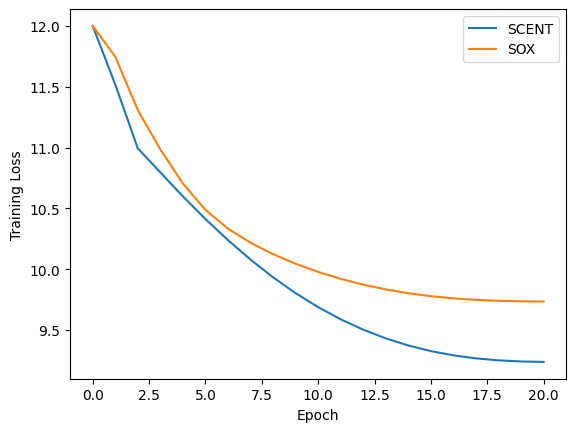

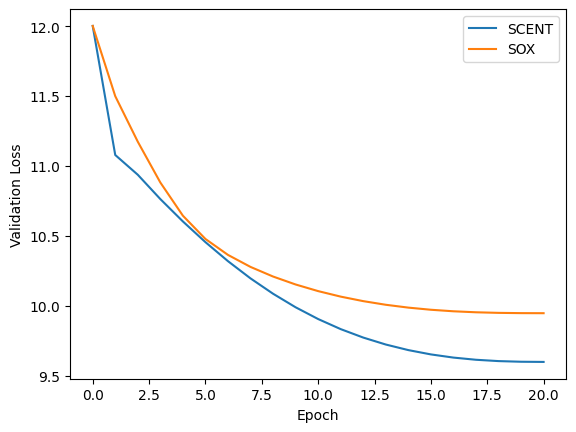

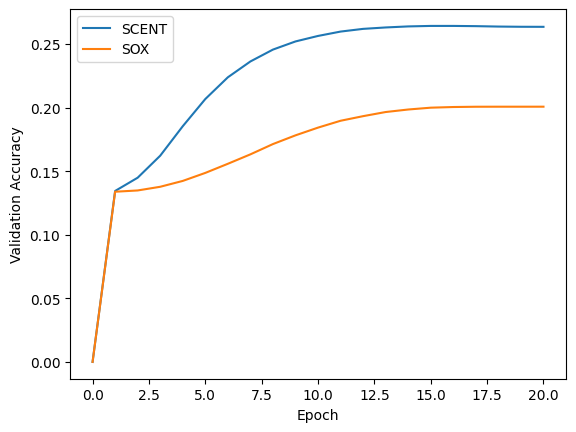

In [ ]:
# plot
import json
import math
import matplotlib.pyplot as plt

for metric, name in zip(["cross_entropy_loss", "val_loss", "val_acc"], ["Training Loss", "Validation Loss", "Validation Accuracy"]):
    if "loss" in metric:
        results_scent = [-math.log(1.0 / num_classes)] + [0.0] * 20
        results_sox = [-math.log(1.0 / num_classes)] + [0.0] * 20
    else:
        results_scent = [1.0 / num_classes] + [0.0] * 20
        results_sox = [1.0 / num_classes] + [0.0] * 20
    with open("./outputs/scent_treeoflife10m_subset/eval_scent_treeoflife10m_subset.jsonl", "r") as f:
        for line in f:
            eval_results = json.loads(line)
            results_scent[eval_results["epoch"]] = eval_results[metric]
    with open("./outputs/sox_treeoflife10m_subset/eval_sox_treeoflife10m_subset.jsonl", "r") as f:
        for line in f:
            eval_results = json.loads(line)
            results_sox[eval_results["epoch"]] = eval_results[metric]

    fig, ax = plt.subplots()
    ax.plot(results_scent, label="SCENT")
    ax.plot(results_sox, label="SOX")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(name)
    ax.legend()

plt.show()


Cross-Entropy loss on training and validation datasets
| Method | Training Loss | Validation Loss | Validation Accuracy |
| -- | -- | -- | -- |
| SCENT | 9.24 | 9.60 | 0.26 |
| SOX | 9.73 | 9.95 | 0.20 |